# Descarcam datele

In [ ]:
import numpy as np
import pandas as pd
import kagglehub
from tensorflow.keras.utils import to_categorical

# Descarcare date
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
train_df = pd.read_csv(f"{path}/mitbih_train.csv", header=None)
test_df = pd.read_csv(f"{path}/mitbih_test.csv", header=None)

# Separare semnale si etichete
X_train_raw = train_df.iloc[:, :-1].values
y_train = to_categorical(train_df.iloc[:, -1].values)
X_test_raw = test_df.iloc[:, :-1].values
y_test = to_categorical(test_df.iloc[:, -1].values)

# Etichetele claselor
class_names = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']

print("Datele au fost incarcate cu succes.")

Using Colab cache for faster access to the 'heartbeat' dataset.
Datele au fost incarcate cu succes.


# Afisarea cate unui exemplu din fiecare clasa

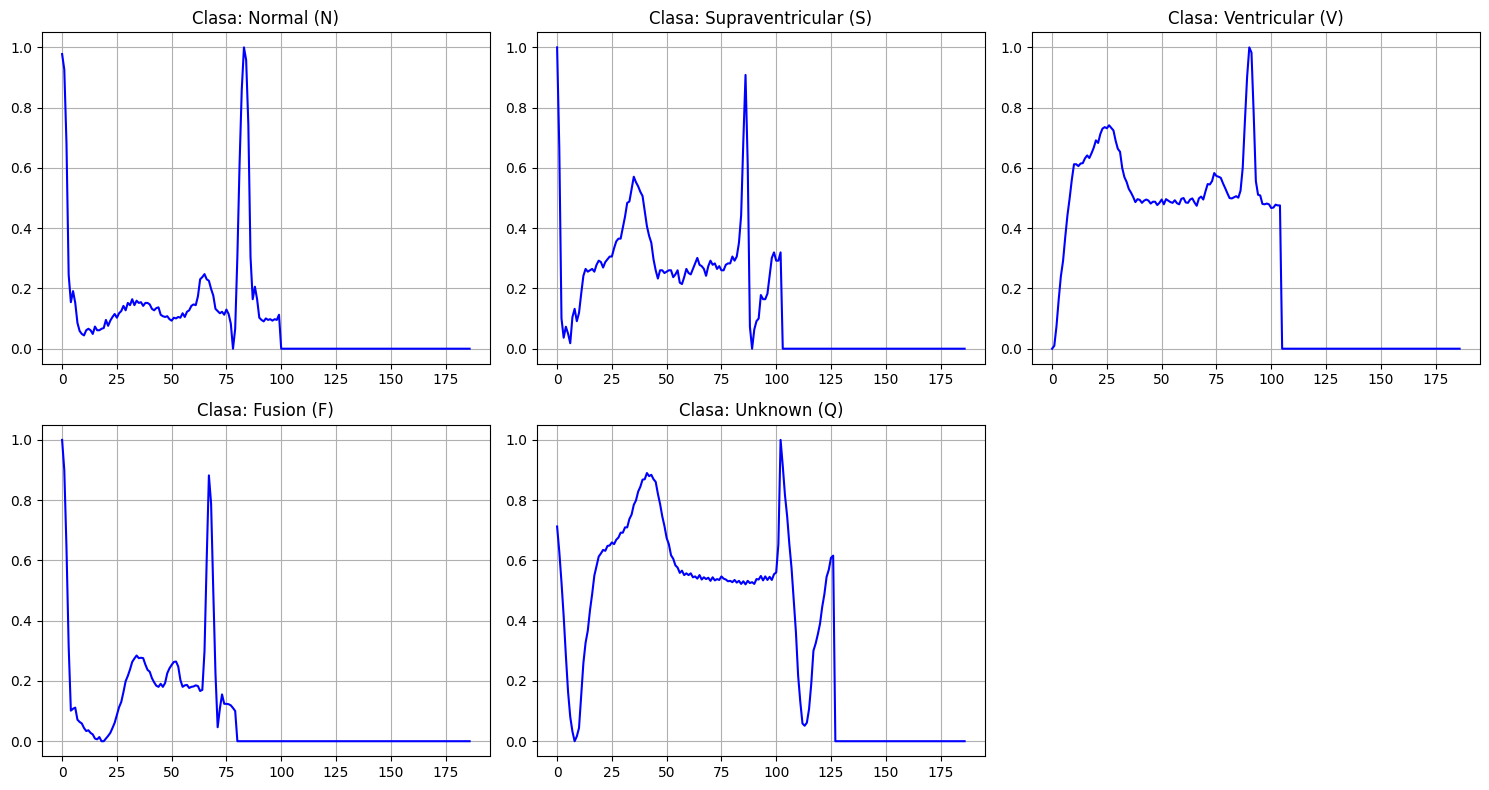

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for i in range(5):
    idx = np.where(train_df.iloc[:, -1] == i)[0][0]
    signal = X_train_raw[idx]

    plt.subplot(2, 3, i+1)
    plt.plot(signal, color='blue')
    plt.title(f"Clasa: {class_names[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()

# Model baseline

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Activation, Add, GlobalAveragePooling1D, Dense, Dropout, MaxPooling1D
from tensorflow.keras.models import Model

# Pregatire date pentru 1 canal
X_train_base = X_train_raw.reshape(-1, 187, 1).astype('float32')
X_test_base = X_test_raw.reshape(-1, 187, 1).astype('float32')

# Arhitectura
inputs = Input(shape=(187, 1))
x = Conv1D(64, 7, padding='same', activation='relu')(inputs)
x = MaxPooling1D(2)(x)
x = Conv1D(128, 5, padding='same', activation='relu')(x)
x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(5, activation='softmax')(x)

model_base = Model(inputs, outputs, name="Model_Normal")
model_base.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_base = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
]

print("Antrenare Model Normal...")
history_base = model_base.fit(X_train_base, y_train, validation_data=(X_test_base, y_test),
                              epochs=10, batch_size=128, callbacks=callbacks_base, verbose=1)

# Salvam modelul pentru etapa de vizualizare
model_base.save("model_normal.keras")

Antrenare Model Normal...
Epoch 1/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8372 - loss: 0.5759 - val_accuracy: 0.8580 - val_loss: 0.4980
Epoch 2/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8874 - loss: 0.3848 - val_accuracy: 0.8938 - val_loss: 0.3658
Epoch 3/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9018 - loss: 0.3427 - val_accuracy: 0.9064 - val_loss: 0.3288
Epoch 4/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9100 - loss: 0.3097 - val_accuracy: 0.9094 - val_loss: 0.3176
Epoch 5/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9151 - loss: 0.2894 - val_accuracy: 0.9149 - val_loss: 0.2924
Epoch 6/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9205 - loss: 0.2688 - val_accuracy: 0.9283 - val_loss: 0.2608
Epoch 7/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9287 - loss: 0.2456 - val_accuracy: 0.9322 - val_loss: 0.2382
Epoch 8/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9347 - loss

# GL

In [ ]:
from scipy.signal import lfilter

# Definitia matematica GL
def apply_gl(data, alpha=0.6, window=15):
    w = np.zeros(window)
    w[0] = 1.0
    for m in range(1, window):
        w[m] = w[m-1] * (1 - (alpha + 1) / m)
    return lfilter(w, [1.0], data, axis=1).astype('float32')

# Preprocesare
X_train_gl_feat = apply_gl(X_train_raw)
X_test_gl_feat = apply_gl(X_test_raw)

# # Hibridizare (Brut + GL)
# X_train_gl = np.stack([X_train_raw, X_train_gl_feat], axis=-1)
# X_test_gl = np.stack([X_test_raw, X_test_gl_feat], axis=-1)

# # Arhitectura pentru 2 canale
# inputs_gl = Input(shape=(187, 2))
# x = Conv1D(64, 7, padding='same', activation='relu')(inputs_gl)
# x = MaxPooling1D(2)(x)
# x = Conv1D(128, 5, padding='same', activation='relu')(x)
# x = GlobalAveragePooling1D()(x)
# x = Dense(64, activation='relu')(x)
# outputs_gl = Dense(5, activation='softmax')(x)

# model_gl = Model(inputs_gl, outputs_gl, name="Model_GL")
# model_gl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# callbacks_gl = [
#     tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
# ]

# print("Antrenare Model GL...")
# history_gl = model_gl.fit(X_train_gl, y_train, validation_data=(X_test_gl, y_test),
#                           epochs=10, batch_size=128, callbacks=callbacks_gl, verbose=1)

# model_gl.save("model_gl.keras")

# CAPUTO

In [ ]:
from scipy.signal import filtfilt
from scipy.special import gamma

# Definitia matematica Caputo
def apply_caputo(data, alpha=0.6, window=15):
    j = np.arange(window)
    weights = ((j + 1)**(1 - alpha) - j**(1 - alpha)) / gamma(2 - alpha)
    dx = np.diff(data, axis=1, prepend=data[:, 0:1])
    return filtfilt(weights, [1.0], dx, axis=1).astype('float32')

# Preprocesare
X_train_cap_feat = apply_caputo(X_train_raw)
X_test_cap_feat = apply_caputo(X_test_raw)

# # Hibridizare (Brut + Caputo)
# X_train_cap = np.stack([X_train_raw, X_train_cap_feat], axis=-1)
# X_test_cap = np.stack([X_test_raw, X_test_cap_feat], axis=-1)

# # Arhitectura pentru 2 canale
# inputs_cap = Input(shape=(187, 2))
# x = Conv1D(64, 7, padding='same', activation='relu')(inputs_cap)
# x = MaxPooling1D(2)(x)
# x = Conv1D(128, 5, padding='same', activation='relu')(x)
# x = GlobalAveragePooling1D()(x)
# x = Dense(64, activation='relu')(x)
# outputs_cap = Dense(5, activation='softmax')(x)

# model_caputo = Model(inputs_cap, outputs_cap, name="Model_Caputo")
# model_caputo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# callbacks_cap = [
#     tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
# ]

# print("Antrenare Model Caputo...")
# history_cap = model_caputo.fit(X_train_cap, y_train, validation_data=(X_test_cap, y_test),
#                                epochs=10, batch_size=128, callbacks=callbacks_cap, verbose=1)

# model_caputo.save("model_caputo.keras")

Generare vizualizari predictii...


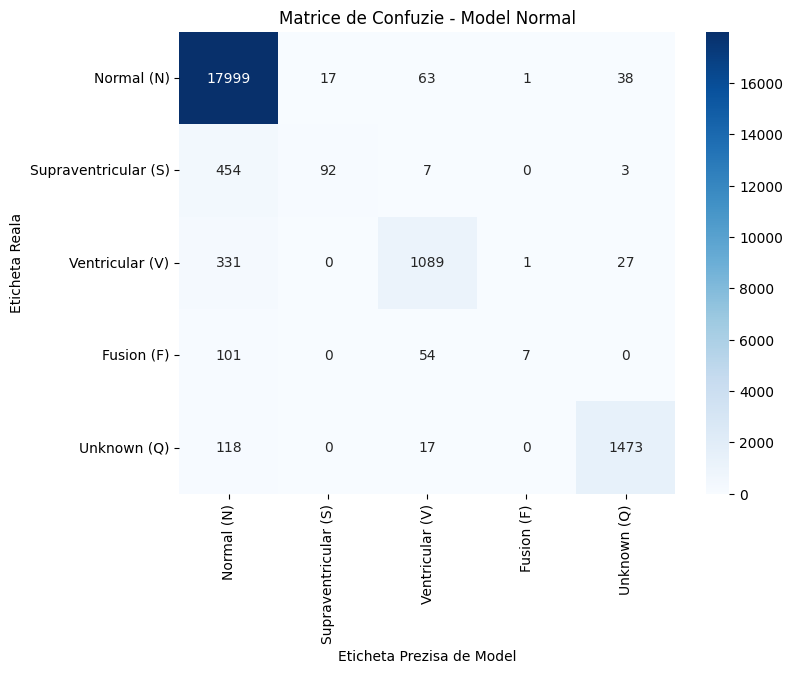

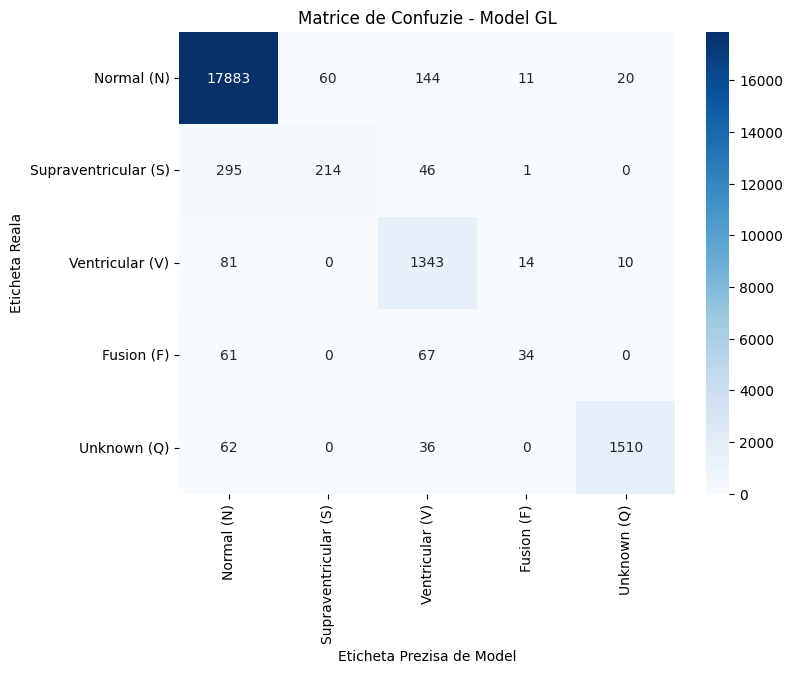

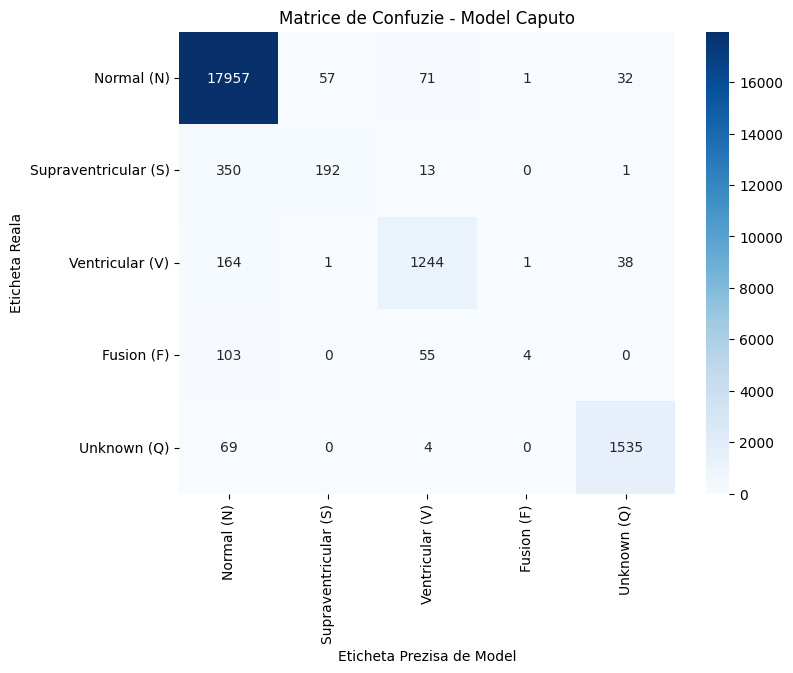

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_data, title):
    y_pred = model.predict(X_data, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_classes, y_pred_classes)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Eticheta Reala')
    plt.xlabel('Eticheta Prezisa de Model')
    plt.show()

print("Generare vizualizari predictii...")
plot_confusion_matrix(model_base, X_test_base, "Matrice de Confuzie - Model Normal")
plot_confusion_matrix(model_gl, X_test_gl, "Matrice de Confuzie - Model GL")
plot_confusion_matrix(model_caputo, X_test_cap, "Matrice de Confuzie - Model Caputo")

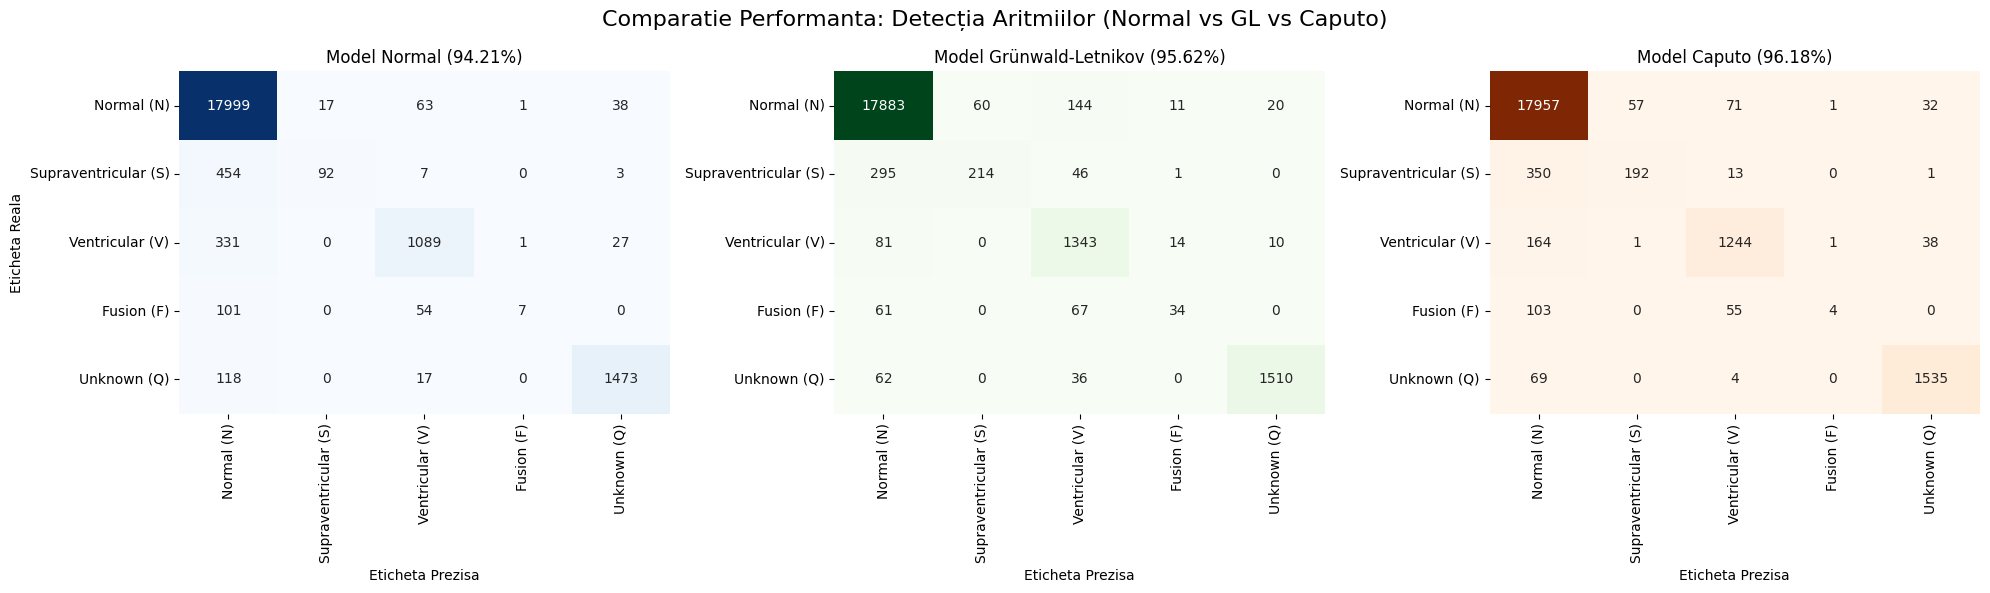

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def get_cm(model, X_data):
    y_pred = model.predict(X_data, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    return confusion_matrix(y_true_classes, y_pred_classes)

# Calculam matricele
cm_base = get_cm(model_base, X_test_base)
cm_gl = get_cm(model_gl, X_test_gl)
cm_caputo = get_cm(model_caputo, X_test_cap)

# Generam graficul comparativ
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plt.suptitle('Comparatie Performanta: Detecția Aritmiilor (Normal vs GL vs Caputo)', fontsize=16)

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[0].set_title('Model Normal (94.21%)')
axes[0].set_ylabel('Eticheta Reala')
axes[0].set_xlabel('Eticheta Prezisa')

sns.heatmap(cm_gl, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[1].set_title('Model Grünwald-Letnikov (95.62%)')
axes[1].set_xlabel('Eticheta Prezisa')

sns.heatmap(cm_caputo, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[2].set_title('Model Caputo (96.18%)')
axes[2].set_xlabel('Eticheta Prezisa')

plt.tight_layout()
plt.show()

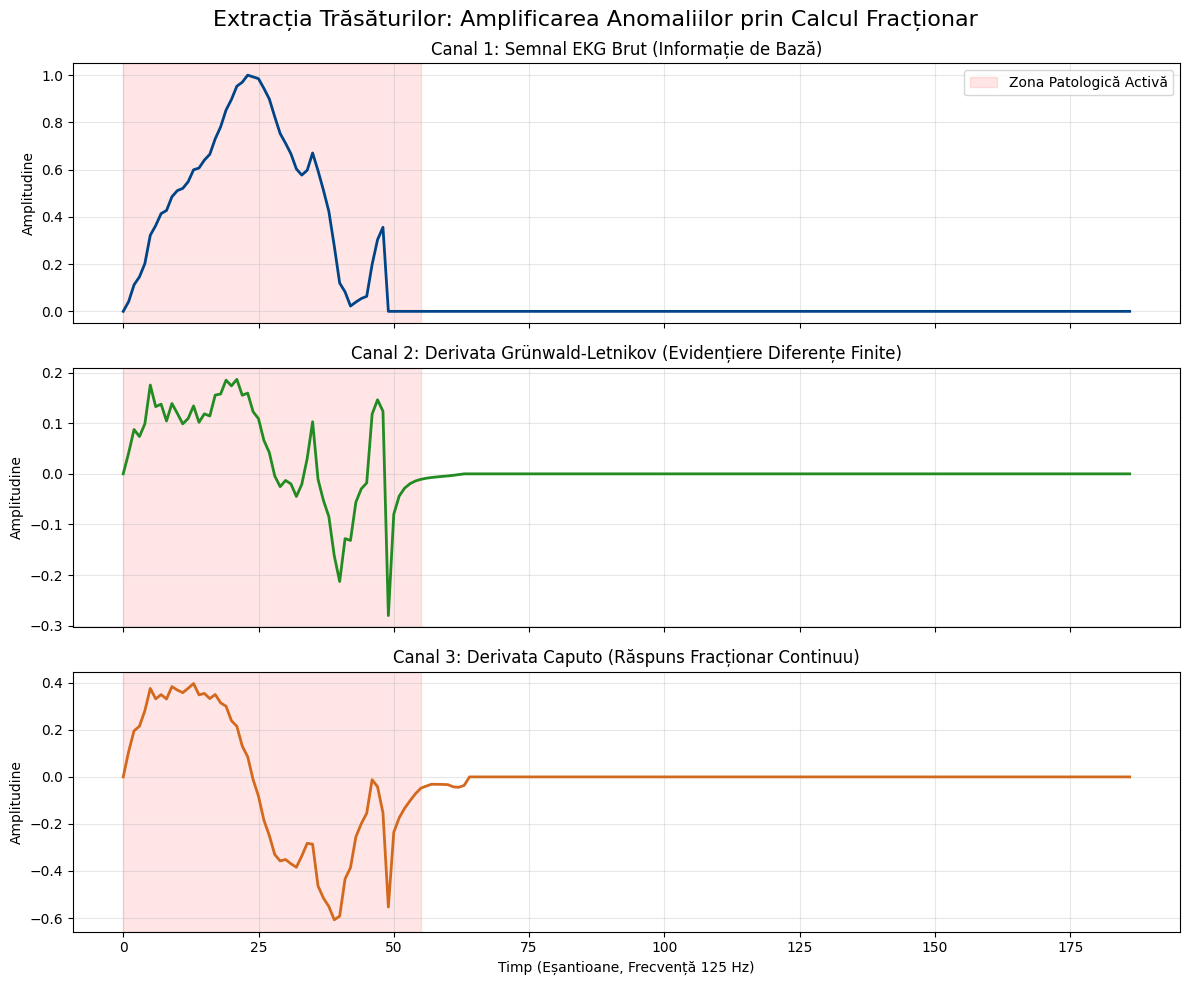

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extragem aceeasi bataie
target_class = 2
exemplu_idx = np.where(np.argmax(y_test, axis=1) == target_class)[0][0]

semnal_brut = X_test_raw[exemplu_idx]
semnal_brut_2d = semnal_brut.reshape(1, -1)
semnal_gl = apply_gl(semnal_brut_2d)[0]
semnal_caputo = apply_caputo(semnal_brut_2d)[0]

# Generam graficul ajustat
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Extracția Trăsăturilor: Amplificarea Anomaliilor prin Calcul Fracționar', fontsize=16)

ax1.plot(semnal_brut, color='#004488', linewidth=2)
ax1.set_title('Canal 1: Semnal EKG Brut (Informație de Bază)')
ax1.grid(True, alpha=0.3)
ax1.set_ylabel('Amplitudine')

ax2.plot(semnal_gl, color='#228B22', linewidth=2)
ax2.set_title('Canal 2: Derivata Grünwald-Letnikov (Evidențiere Diferențe Finite)')
ax2.grid(True, alpha=0.3)
ax2.set_ylabel('Amplitudine')

ax3.plot(semnal_caputo, color='#D2691E', linewidth=2)
ax3.set_title('Canal 3: Derivata Caputo (Răspuns Fracționar Continuu)')
ax3.grid(True, alpha=0.3)
ax3.set_ylabel('Amplitudine')
ax3.set_xlabel('Timp (Eșantioane, Frecvență 125 Hz)')

# Zona de interes corectata
for ax in [ax1, ax2, ax3]:
    ax.axvspan(0, 55, color='red', alpha=0.1, label='Zona Patologică Activă')

ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()

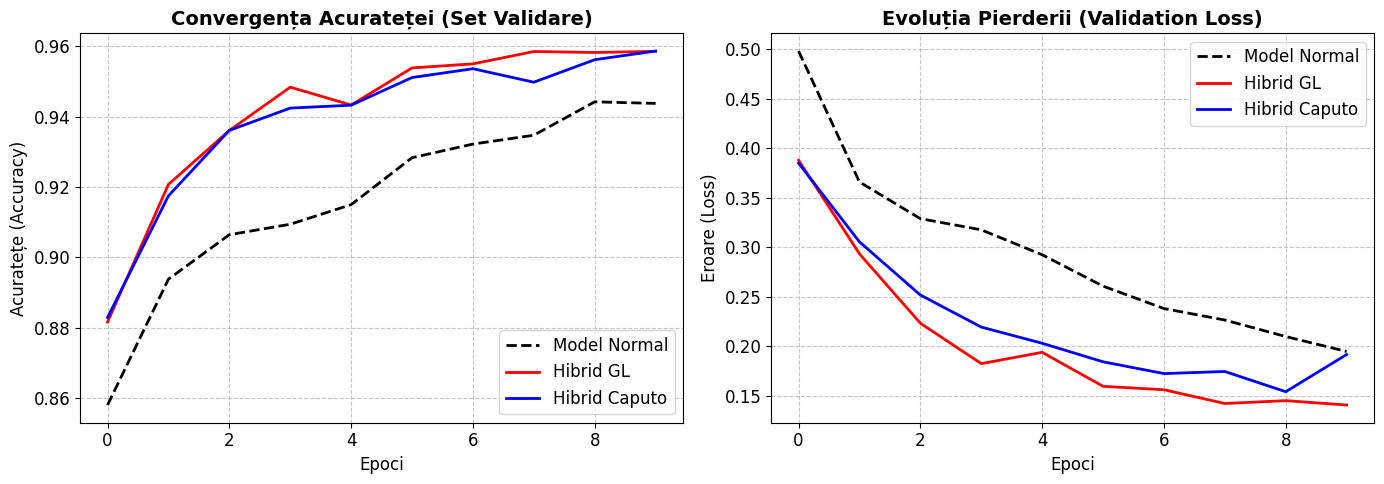

Graficul a fost salvat cu succes sub numele 'convergenta_si_overfitting.png'


In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
#
# Graficul pentru Acuratețe (Convergența pe setul de validare)
# ---------------------------------------------------------------
ax1.plot(history_base.history['val_accuracy'], label='Model Normal', color='black', linestyle='--', linewidth=2)
ax1.plot(history_gl.history['val_accuracy'], label='Hibrid GL', color='red', linewidth=2)
ax1.plot(history_cap.history['val_accuracy'], label='Hibrid Caputo', color='blue', linewidth=2)

ax1.set_title('Convergența Acurateței (Set Validare)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Epoci', fontsize=12)
ax1.set_ylabel('Acuratețe (Accuracy)', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.7)

#
#  Graficul pentru Eroare / Loss
# -----------------------------------------------------------------------------------------
ax2.plot(history_base.history['val_loss'], label='Model Normal', color='black', linestyle='--', linewidth=2)
ax2.plot(history_gl.history['val_loss'], label='Hibrid GL', color='red', linewidth=2)
ax2.plot(history_cap.history['val_loss'], label='Hibrid Caputo', color='blue', linewidth=2)

ax2.set_title('Evoluția Pierderii (Validation Loss)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Epoci', fontsize=12)
ax2.set_ylabel('Eroare (Loss)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('convergenta_si_overfitting.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graficul a fost salvat cu succes sub numele 'convergenta_si_overfitting.png'")

In [ ]:
####################### OPTIMIZARE SI OBTINEREA PERFORMANTEI ###############
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Asiguram tensorul cu 3 canale (Brut + GL + Caputo)
X_train_fusion = np.stack([X_train_raw, X_train_gl_feat, X_train_cap_feat], axis=-1)
X_test_fusion = np.stack([X_test_raw, X_test_gl_feat, X_test_cap_feat], axis=-1)

# Arhitectura Optimizata
inputs_fusion = Input(shape=(187, 3))
x = Conv1D(64, 7, padding='same', activation='relu')(inputs_fusion)
x = MaxPooling1D(2)(x)
x = Conv1D(128, 5, padding='same', activation='relu')(x)
x = GlobalAveragePooling1D()(x)

# OPTIMIZARE: Adaugam Dropout //pentru a forta reteaua sa invete mai robust
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
outputs_fusion = Dense(5, activation='softmax')(x)

model_fusion = Model(inputs_fusion, outputs_fusion, name="Model_Suprem_Optimizat")
model_fusion.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks de Optimizare
callbacks_optim = [
    # Opreste antrenarea daca nu mai scade val_loss
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),

    # OPTIMIZARE: Daca val_loss stagneaza 2 epoci, injumatatim rata de invatare
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# Antrenarea (FARA class weights de data asta)
print("Antrenare Model Suprem (Optimizat cu Dropout si LR Decay)...")
history_fusion = model_fusion.fit(X_train_fusion, y_train,
                                  validation_data=(X_test_fusion, y_test),
                                  epochs=10, batch_size=128,
                                  callbacks=callbacks_optim,
                                  verbose=1)

Antrenare Model Suprem (Optimizat cu Dropout si LR Decay)...
Epoch 1/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8491 - loss: 0.5207 - val_accuracy: 0.8871 - val_loss: 0.3725 - learning_rate: 0.0010
Epoch 2/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9117 - loss: 0.3151 - val_accuracy: 0.9361 - val_loss: 0.2453 - learning_rate: 0.0010
Epoch 3/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9365 - loss: 0.2325 - val_accuracy: 0.9461 - val_loss: 0.1933 - learning_rate: 0.0010
Epoch 4/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9435 - loss: 0.1957 - val_accuracy: 0.9477 - val_loss: 0.1790 - learning_rate: 0.0010
Epoch 5/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9508 - loss: 0.1767 - val_accuracy: 0.9565 - val_loss: 0.1542 - learning_rate: 0.0010
Epoch 6/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9548 - loss: 0.1632 - val_accuracy: 0.9596 - val_loss: 0.1433 - learning_rate: 0.0010
Epoch 7/10
685/685 ━━━━━

Generare predictii pentru Modelul Suprem...


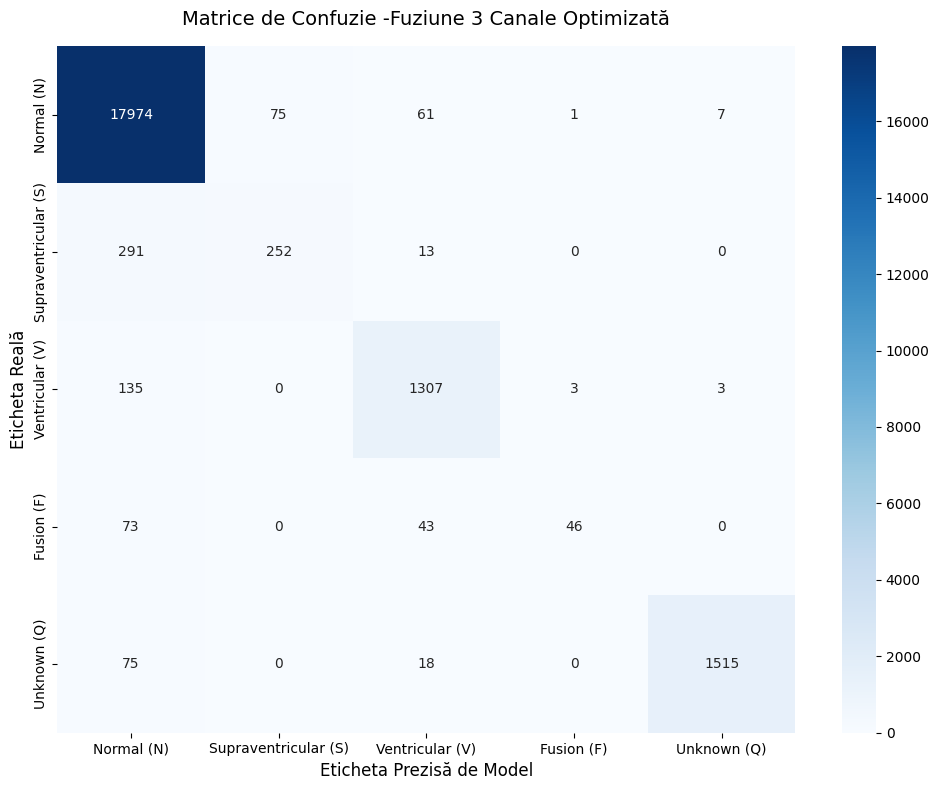

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Facem predictiile pe setul de test folosind modelul fuzionat
print("Generare predictii pentru Modelul Suprem...")
y_pred_fusion = model_fusion.predict(X_test_fusion, verbose=0)
y_pred_classes_fusion = np.argmax(y_pred_fusion, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Calculam matricea de confuzie
cm_fusion = confusion_matrix(y_true_classes, y_pred_classes_fusion)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_fusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title("Matrice de Confuzie -Fuziune 3 Canale Optimizată", fontsize=14, pad=15)
plt.ylabel('Eticheta Reală', fontsize=12)
plt.xlabel('Eticheta Prezisă de Model', fontsize=12)

# Ajustam marginile pentru a nu taia textul
plt.tight_layout()
plt.show()

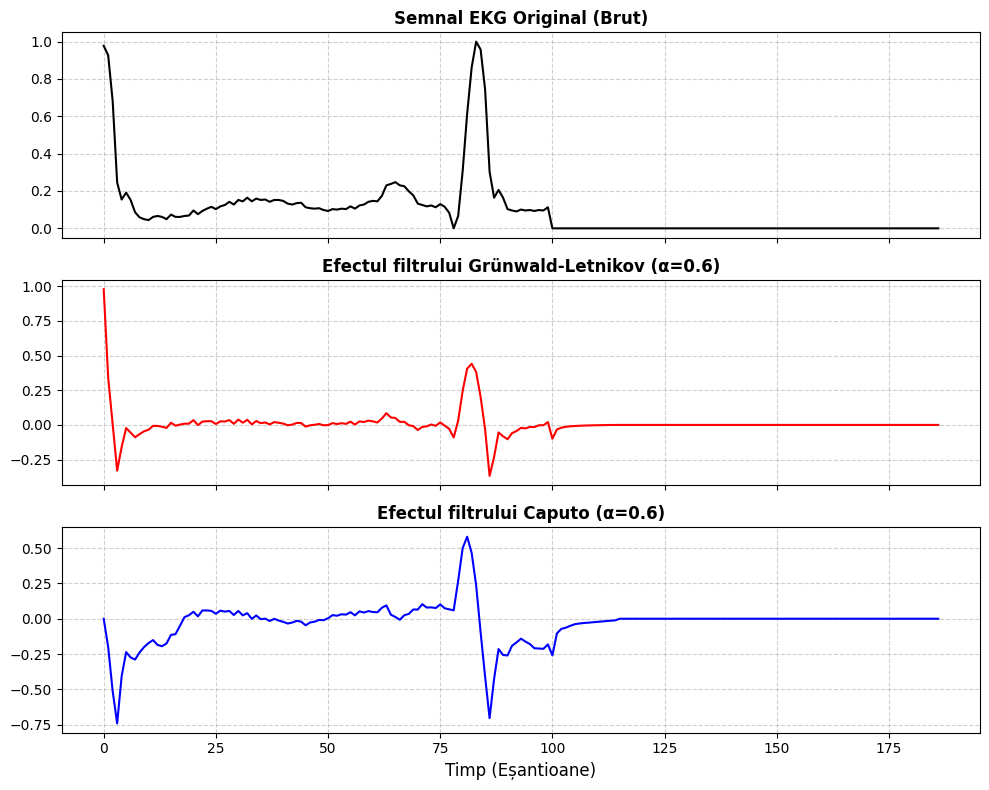

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, filtfilt
from scipy.special import gamma

def apply_gl_local(data, alpha=0.6, window=15):
    w = np.zeros(window)
    w[0] = 1.0
    for m in range(1, window):
        w[m] = w[m-1] * (1 - (alpha + 1) / m)
    return lfilter(w, [1.0], data, axis=1).astype('float32')

def apply_caputo_local(data, alpha=0.6, window=15):
    j = np.arange(window)
    weights = ((j + 1)**(1 - alpha) - j**(1 - alpha)) / gamma(2 - alpha)
    dx = np.diff(data, axis=1, prepend=data[:, 0:1])
    return filtfilt(weights, [1.0], dx, axis=1).astype('float32')

# Extragem prima bătaie
semnal_brut_2d = X_train_raw[0:1]

# filtrele DOAR pentru această bătaie
semnal_gl = apply_gl_local(semnal_brut_2d, alpha=0.6)[0]
semnal_caputo = apply_caputo_local(semnal_brut_2d, alpha=0.6)[0]
semnal_brut = semnal_brut_2d[0]


fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(semnal_brut, color='black', linewidth=1.5)
ax1.set_title('Semnal EKG Original (Brut)', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(semnal_gl, color='red', linewidth=1.5)
ax2.set_title('Efectul filtrului Grünwald-Letnikov (\u03B1=0.6)', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)

ax3.plot(semnal_caputo, color='blue', linewidth=1.5)
ax3.set_title('Efectul filtrului Caputo (\u03B1=0.6)', fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Timp (Eșantioane)', fontsize=12)
plt.tight_layout()
plt.savefig('dovada_vizuala_filtre.png', dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graficul pentru Acuratețe (Convergența pe setul de validare)

ax1.plot(history_base.history['val_accuracy'], label='Model Normal', color='black', linestyle='--', linewidth=2)
ax1.plot(history_gl.history['val_accuracy'], label='Hibrid GL', color='red', linewidth=2)
ax1.plot(history_cap.history['val_accuracy'], label='Hibrid Caputo', color='blue', linewidth=2)

ax1.set_title('Convergența Acurateței (Set Validare)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Epoci', fontsize=12)
ax1.set_ylabel('Acuratețe (Accuracy)', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.7)

# ---------------------------------------------------------------------------------------------------------------------
#  Graficul pentru Eroare / Loss

ax2.plot(history_base.history['val_loss'], label='Model Normal', color='black', linestyle='--', linewidth=2)
ax2.plot(history_gl.history['val_loss'], label='Hibrid GL', color='red', linewidth=2)
ax2.plot(history_cap.history['val_loss'], label='Hibrid Caputo', color='blue', linewidth=2)

ax2.set_title('Evoluția Pierderii (Validation Loss)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Epoci', fontsize=12)
ax2.set_ylabel('Eroare (Loss)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig('convergenta_si_overfitting.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graficul a fost salvat cu succes sub numele 'convergenta_si_overfitting.png'")